In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import string
from scipy import stats
from scipy.stats import gaussian_kde

import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patheffects as path_effects
from matplotlib.patches import PathPatch
import matplotlib.cm as cm
import matplotlib.colors as colors


import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings('ignore')

In [2]:
def compute_fwrca(df_crashes, df_anom, state_dict, var_prefix='Precip'):
    """
    Computes the relationship between crash anomalies (FWRCA) and precipitation/SWE anomalies.
    
    Parameters:
        df_crashes: DataFrame with crash data, including STATE, YEAR, MONTH
        df_anom: DataFrame with anomaly data (e.g., Precip_Anomaly_XX and ENSO_Value)
        state_dict: Dict mapping state names to abbreviations (e.g., {'Virginia': 'VA'})
        var_prefix: 'Precip' or 'SWE'
    
    Returns:
        DataFrame with regression results (R², p-values, slopes, etc.)
    """
    from scipy import stats

    DJF_MONTHS = [12, 1, 2]
    results = []

    for state, abbr in state_dict.items():
        
        if var_prefix == 'Precip':
            total_col = f'Precip_Anomaly_{abbr}'
        elif var_prefix == 'SWE':
            total_col = f'snow_water_equivalent_{abbr}'
        else:
            print(f"Unknown var_prefix {var_prefix}, skipping...")
            continue
        enso_col = 'ENSO_Value'

        if total_col not in df_anom.columns or enso_col not in df_anom.columns:
            print(f"Missing required columns for {abbr} ({var_prefix}), skipping...")
            continue

        state_df = df_crashes[df_crashes['STATE'] == state]
        if state_df.empty:
            print(f"No crash data for {abbr}, skipping...")
            continue

        # Compute FWRCA
        crash_counts = state_df.groupby(['YEAR', 'MONTH']).size().reset_index(name='CRASH_COUNT')
        crash_counts = crash_counts[crash_counts['MONTH'].isin(DJF_MONTHS)]
        if crash_counts.empty:
            print(f"No DJF crash data for {abbr}, skipping...")
            continue

        monthly_avg = crash_counts.groupby('MONTH')['CRASH_COUNT'].mean()
        crash_counts['FWRCA'] = crash_counts.apply(
            lambda row: row['CRASH_COUNT'] - monthly_avg[row['MONTH']], axis=1
        )

        # Ensure int type for merge keys
        crash_counts['MONTH'] = crash_counts['MONTH'].astype(int)
        df_anom['Month'] = df_anom['Month'].astype(int)
        df_anom['YEAR'] = df_anom['YEAR'].astype(int)

        # Merge crash anomalies with climate anomalies
        merged = crash_counts.merge(
            df_anom[['YEAR', 'Month', total_col, enso_col]],
            left_on=['YEAR', 'MONTH'],
            right_on=['YEAR', 'Month'],
            how='inner'
        )

        if merged.empty:
            print(f"No matched anomaly data for {abbr}, skipping...")
            continue

        # Total anomaly regression
        slope_total, intercept_total, r_total, p_total, stderr_total = stats.linregress(
            merged[total_col], merged['FWRCA']
        )

        # ENSO-only regression
        slope_enso, intercept_enso, r_enso, p_enso, stderr_enso = stats.linregress(
            merged[enso_col], merged['FWRCA']
        )

        results.append({
            'State': abbr,
            'Variable': var_prefix,
            'Slope_Total': slope_total,
            'Intercept_Total': intercept_total,
            'R_Value_Total': r_total,
            'R_Squared_Total': r_total**2,
            'P_Value_Total': p_total,
            'Slope_ENSO': slope_enso,
            'Intercept_ENSO': intercept_enso,
            'R_Value_ENSO': r_enso,
            'R_Squared_ENSO': r_enso**2,
            'P_Value_ENSO': p_enso
        })

    return pd.DataFrame(results)


In [3]:
def compute_enso_avg_anomalies(df, variable_prefix, enso_col='ENSO_Value', threshold_el=0.5, threshold_ln=-0.5, exclude_states=None):
    """
    Compute average anomalies for El Niño and La Niña states given a DataFrame.

    Parameters:
    - df: input DataFrame
    - variable_prefix: str, column prefix to select relevant state anomaly columns
    - enso_col: str, column name of ENSO index
    - threshold_el: float, El Niño threshold (default 0.5)
    - threshold_ln: float, La Niña threshold (default -0.5)
    - exclude_states: set or list of states to exclude

    Returns:
    - el_nino_df, la_nina_df: DataFrames with average anomalies by state
    """

    if exclude_states is None:
        exclude_states = {'DC', 'AK', 'HI', 'PR', 'PRCP'}

    # Select columns with the prefix excluding unwanted states
    state_cols = [
        col for col in df.columns
        if col.startswith(variable_prefix) and col.split('_')[-1] not in exclude_states
    ]

    # Filter data by ENSO phase
    el_nino_data = df[df[enso_col] >= threshold_el]
    la_nina_data = df[df[enso_col] <= threshold_ln]

    # Compute averages using your existing helper
    el_nino_averages = compute_avg_anomalies(el_nino_data, state_cols)
    la_nina_averages = compute_avg_anomalies(la_nina_data, state_cols)

    # Convert to DataFrame and sort
    el_nino_df = pd.DataFrame.from_dict(el_nino_averages, orient='index', columns=['Avg_Anomaly']).sort_values('Avg_Anomaly')
    la_nina_df = pd.DataFrame.from_dict(la_nina_averages, orient='index', columns=['Avg_Anomaly']).sort_values('Avg_Anomaly')

    return el_nino_df, la_nina_df


In [4]:
def plot_crash_anomalies(df):
    color_pos = '#D55E00'  # orange
    color_neg = '#0072B2'  # blue
    color_neutral = '#999999'  # grey
    panel_bg = '#f7f7f7'     # light gray background
    font_size = 14

    dates = df['DATE']
    anomalies = df['CRASH_ANOMALY'].values

    fig, ax = plt.subplots(figsize=(18, 6))

    x = np.arange(len(anomalies))

    # Plot black line (anomalies)
    ax.plot(x, anomalies, color='black', linewidth=1.5, alpha=0.3, label='_nolegend_')

    # Masks with no overlap
    mask_pos = anomalies >= 0
    mask_neg = anomalies < 0

    # Fill neutral is not really used here, so omit or if you want threshold use something else.
    # Here just positive and negative:
    ax.fill_between(x, 0, anomalies, where=mask_pos,
                    facecolor=color_pos, alpha=0.6, interpolate=True, label='Positive Anomaly')
    ax.fill_between(x, 0, anomalies, where=mask_neg,
                    facecolor=color_neg, alpha=0.6, interpolate=True, label='Negative Anomaly')

    # Bold title and labels
    ax.set_title('Monthly Fatal Crash Anomalies (1981–2019)', fontsize=font_size + 4, fontweight='bold', pad=15)
    ax.set_ylabel('Crash Anomaly', fontsize=font_size + 1, fontweight='bold')
    ax.set_xlabel('Time', fontsize=font_size + 1, fontweight='bold')

    # X ticks every year: find indices for start of each year
    years = df['DATE'].dt.year.unique()
    # Find indices where year changes to set ticks:
    year_start_indices = [df.index[df['DATE'].dt.year == y][0] for y in years]

    ax.set_xticks(year_start_indices)
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=font_size, fontweight='bold')

    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5)
    ax.axhline(0, color='gray', linewidth=1, linestyle='--')

    # Bold spines
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Bold ticks
    ax.tick_params(axis='both', which='major', labelsize=font_size, width=1.5, length=6)

    # Grid lines on y axis only
    ax.grid(axis='y', linestyle=':', alpha=0.4)

    ax.legend(fontsize=font_size, frameon=False, loc='upper right')

    plt.tight_layout(pad=2.5)
    plt.savefig('../figs/Crash_Anomalies.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

In [5]:
def plot_nino34(df):
    months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
              'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

    mask = (df['YEAR'] >= 1981) & (df['YEAR'] <= 2019)
    filtered = df.loc[mask, ['YEAR'] + months].reset_index(drop=True)

    line_values = filtered[months].values.flatten()
    years = filtered['YEAR']
    n_months = len(months)
    n_bars = len(years) * n_months

    color_pos = '#D55E00'  # orange
    color_neg = '#0072B2'  # blue

    fig, ax = plt.subplots(figsize=(16, 6))
    x = np.arange(len(line_values))

    ax.plot(x, line_values, color='black', linewidth=2, alpha=0.7)

    # Masks
    mask_pos = line_values >= 0.5
    mask_neg = line_values <= -0.5

    # Positive fill between line_values and 0.5
    ax.fill_between(x, 0.5, line_values, where=mask_pos, color=color_pos,
                    alpha=0.7, interpolate=True, label='El Nino ≥ 0.5°C')

    # Negative fill between line_values and -0.5
    ax.fill_between(x, line_values, -0.5, where=mask_neg, color=color_neg,
                    alpha=0.7, interpolate=True, label='La Nina ≤ -0.5°C')

    # Horizontal threshold lines
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(-0.5, color='gray', linestyle='--', linewidth=0.8)

    ax.set_title('Monthly Sea-Surface Temperature Anomalies (1981–2019)', fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel('Year', fontsize=16, fontweight='bold')
    ax.set_ylabel('Sea-Surface Temperature Anomalies (°C)', fontsize=16, fontweight='bold')

    ax.set_xticks([i * n_months for i in range(len(years))])
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=12, fontweight='bold')

    ax.set_xlim(-0.5, n_bars - 0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    ax.legend(fontsize=12, frameon=False, loc='upper right')

    plt.tight_layout()
    plt.savefig('../figs/Nino34.png', dpi=300, facecolor='white')
    plt.show()

In [6]:
def compute_avg_anomalies(data, columns):
    averages = {}
    for col in columns:
        state = col.split('_')[-1]
        averages[state] = data[col].mean()
    return averages

In [7]:
def plot_enso_precip_anomalies(el_nino_dict, la_nina_dict, save_path=None):
    """
    Create a 2-panel horizontal bar plot of state-level precipitation anomalies
    for El Niño and La Niña events. Optimized for an 8.5x11 portrait layout.

    Parameters:
    - el_nino_dict: dict of {state: anomaly} for El Niño
    - la_nina_dict: dict of {state: anomaly} for La Niña
    - save_path: Optional path to save the figure (e.g., '../figs/output.png')
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # Intersecting states, sorted alphabetically
    states = sorted(set(el_nino_dict.keys()) & set(la_nina_dict.keys()))
    el_nino_vals = np.array([el_nino_dict[state] for state in states])
    la_nina_vals = np.array([la_nina_dict[state] for state in states])

    fig, (ax1, ax2) = plt.subplots(ncols=2, sharey=True, figsize=(8.5, 11))

    color_el_nino = '#D55E00'
    color_la_nina = '#0072B2'
    title_size = 12
    label_size = 12
    tick_size = 12

    # Axis limits with margin
    def compute_limits(vals):
        vmin, vmax = vals.min(), vals.max()
        margin = 0.05
        return vmin - margin, vmax + margin

    xmin1, xmax1 = compute_limits(el_nino_vals)
    xmin2, xmax2 = compute_limits(la_nina_vals)

    # Create 0.1 spaced ticks
    def make_ticks(xmin, xmax):
        start = np.floor(xmin * 10) / 10
        end = np.ceil(xmax * 10) / 10
        return np.arange(start, end + 0.1, 0.1)

    ticks1 = make_ticks(xmin1, xmax1)
    ticks2 = make_ticks(xmin2, xmax2)

    # Plot El Niño
    ax1.barh(states, el_nino_vals, color=color_el_nino, edgecolor='black', linewidth=1.2)
    ax1.set_title('a) El Niño', fontsize=title_size, fontweight='bold')
    ax1.set_xlabel('Avg Precipitation Anomaly (mm/day)', fontsize=label_size, fontweight='bold')
    ax1.set_ylabel('State', fontsize=label_size, fontweight='bold')
    ax1.set_xlim(xmax1, xmin1)
    ax1.set_xticks(ticks1)
    ax1.grid(axis='x', linestyle=':', alpha=0.5)
    ax1.tick_params(labelsize=tick_size, width=1.5, length=5)
    ax1.invert_yaxis()
    ax1.invert_xaxis()

    # Plot La Niña
    ax2.barh(states, la_nina_vals, color=color_la_nina, edgecolor='black', linewidth=1.2)
    ax2.set_title('b) La Niña', fontsize=title_size, fontweight='bold')
    ax2.set_xlabel('Avg Precipitation Anomaly (mm/day)', fontsize=label_size, fontweight='bold')
    ax2.set_xlim(xmin2, xmax2)
    ax2.set_xticks(ticks2)
    ax2.grid(axis='x', linestyle=':', alpha=0.5)
    ax2.tick_params(labelsize=tick_size, width=1.5, length=5)

    # Style
    for ax in (ax1, ax2):
        for spine in ax.spines.values():
            spine.set_linewidth(2)

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    if save_path:
        plt.savefig(save_path, dpi=300, facecolor='white')
    plt.show()

In [8]:
def plot_cluster_composites(cluster_comp, cmap='RdBu_r', lon_0=260,
                             suptitle="ERA5 Z500 Anomalies DJF 1981–2019", 
                             nrows=2, ncols=2, levels=np.arange(-90, 100, 10),
                             save_path=None, dpi=300):

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.5, 11.0),
                            subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=lon_0)})

    axs = axs.flatten()
    titles = cluster_comp['names'].values
    freq=cluster_comp['freq'].values
    k = 0

    # Create circular Path in Axes coordinates
    theta = np.linspace(0, 2 * np.pi, 100)
    circle_x = 0.5 + 0.5 * np.cos(theta)
    circle_y = 0.5 + 0.5 * np.sin(theta)
    circle_path = Path(np.column_stack([circle_x, circle_y]))

    for ax, label in zip(axs, string.ascii_lowercase):
        # Apply circular boundary using Path
        ax.set_boundary(circle_path, transform=ax.transAxes)

        ax.set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        #ax.gridlines(draw_labels=False)

        cs = ax.contourf(cluster_comp['lon'].values,
                         cluster_comp['lat'].values,
                         cluster_comp['z'][k, :, :].values,
                         levels=levels,
                         cmap=cmap,
                         extend='both',
                         transform=ccrs.PlateCarree())

        title_text = f"({label}) {titles[k]} ({freq[k]}%)" if freq is not None else titles[k]
        ax.set_title(title_text, loc='center', fontsize='medium', fontweight='bold')
#        ax.text(0.01, 0.99, f"({label})", transform=ax.transAxes,
#                ha='left', va='top', fontsize='large', fontweight='bold')
        k += 1

    # fig.subplots_adjust(bottom=0.1, top=0.92, hspace=0.25)
    fig.subplots_adjust(bottom=0.25, top=0.92, hspace=0.05)
    cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("m")

    fig.suptitle(suptitle, fontsize='x-large')

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

In [9]:
def plot_precip_cluster_composites(cluster_pcomp, titles=None,cmap='BrBG', lon_0=260,
                                    suptitle="CHIRPS Global Precip Anomalies DJF 1981–2019",
                                    nrows=2, ncols=2, levels=np.arange(-1, 1.2, 0.2),
                                    extent=[225, 300, 20, 50],
                                    save_path=None, dpi=300):

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(11.0,8.5),
                            subplot_kw={'projection': ccrs.PlateCarree(central_longitude=lon_0)})
    axs = axs.flatten()
    k = 0

    for ax, label in zip(axs, string.ascii_lowercase):
        # Set map extent
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

        # Filled contour plot
        cs = ax.contourf(cluster_pcomp['lon'].values,
                         cluster_pcomp['lat'].values,
                         cluster_pcomp['precip'][k, :, :].values,
                         levels=levels,
                         cmap=cmap,
                         extend='both',
                         transform=ccrs.PlateCarree())

        # Title with subplot label
        ax.set_title(f"({label}) {titles[k]}", loc='center', fontsize='medium', fontweight='bold')
        k += 1

    # Adjust spacing and add colorbar
    fig.subplots_adjust(bottom=0.25, top=0.90, hspace=0.15)
    cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("mm/day", fontweight='bold')

    # Super title
    #fig.suptitle(suptitle, fontsize='x-large', fontweight='bold')

    # Save or show
    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


In [10]:
def plot_statewise_precip_anomalies(
    gdf_precip, regime_names=None,
    cmap='BrBG',
    suptitle="State-Level Precip Anomalies by Regime (DJF 1981–2019)",
    extent=[-125, -66.5, 24, 50],
    nrows=2, ncols=2,
    save_path=None, dpi=300):

    # Set up color range based on data
    abs_max = np.nanmax(np.abs(gdf_precip['ANOMALY']))
    norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)
    cmap = cm.get_cmap(cmap)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 9),
                            subplot_kw={'projection': ccrs.PlateCarree()})
    axs = axs.flatten()

    regimes = sorted(gdf_precip['REGIME'].dropna().unique())

    for i, (regime, ax) in enumerate(zip(regimes, axs)):
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

        subset = gdf_precip[gdf_precip['REGIME'] == regime]

        # Plot filled states
        subset.plot(column='ANOMALY',
                    cmap=cmap,
                    norm=norm,
                    linewidth=0.5,
                    edgecolor='black',
                    ax=ax,
                    transform=ccrs.PlateCarree())

        label = regime_names.get(regime, f"Regime {regime}") if regime_names else f"Regime {regime}"
        ax.set_title(f"({string.ascii_lowercase[i]}) {label}", fontsize='medium', fontweight='bold')

    # Colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []  # required for older matplotlib

    fig.subplots_adjust(bottom=0.15, top=0.92, hspace=0.2)
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Precip Anomaly (mm/day)", fontweight='bold')

    # Super title
    fig.suptitle(suptitle, fontsize=16, fontweight='bold')

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


In [11]:
def plot_enso_anomaly_maps(el_nino_avgs, la_nina_avgs, state_centers, save_path='../figs/enso_precip_anomalies.png'):

    fig, axes = plt.subplots(nrows=2, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})

    cmap = plt.cm.BrBG
    vmin, vmax = -0.5, 0.5
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    titles = ['a) El Niño', 'b) La Niña']
    data_dicts = [el_nino_avgs, la_nina_avgs]

    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())
    
    
    for ax, title, data in zip(axes, titles, data_dicts):
        ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

        patches = []
        values = []

        for state in states:
            abbrev = state.attributes['postal']
            if abbrev in data:
                geom = state.geometry
                if geom.geom_type == 'Polygon':
                    polygons = [geom]
                elif geom.geom_type == 'MultiPolygon':
                    polygons = list(geom.geoms)
                else:
                    continue
                for polygon in polygons:
                    patches.append(Polygon(np.array(polygon.exterior.coords.xy).T))
                    values.append(data[abbrev])

        pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
        pc.set_array(np.array(values))
        ax.add_collection(pc)

        for state, value in data.items():            
            if state in state_centers:
                
                lon, lat = state_centers[state]
                ax.text(lon, lat, f"{state}\n{value:.2f}", ha='center', va='center',
                        fontsize=8, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=14, fontweight='bold', pad=12)

    # Shared colorbar at bottom
    #sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    #sm.set_array([])
    #cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
    #                    fraction=0.04, pad=0.05)
    #cbar.set_label('Precipitation Anomaly (mm/day)', fontsize=14)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        orientation='horizontal',
        fraction=0.04,
        pad=0.07,
        extend='both'  # <-- enables arrows at both ends
    )    
    cbar.set_label('Precipitation Anomaly (mm/day)', fontsize=14)
    #plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.subplots_adjust(left=0.07, right=0.97, top=0.97, bottom=0.2, hspace=0.08)    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [12]:
def plot_swe_anomaly_maps(el_nino_avgs, la_nina_avgs, state_centers, save_path='swe_anomalies_enso.png'):
 
    # Setup
    fig, axes = plt.subplots(nrows=2, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})
    titles = ['a) El Niño', 'b) La Niña']
    data_dicts = [el_nino_avgs, la_nina_avgs]

    cmap = plt.cm.BrBG
    vmin, vmax = -0.01, 0.01
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Shapefile
    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())

    for ax, title, data in zip(axes, titles, data_dicts):
        ax.set_extent([-125, -66, 24, 50])
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

        patches, values = [], []
        for state in states:
            abbrev = state.attributes['postal']
            if abbrev in data:
                geom = state.geometry
                polygons = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
                for polygon in polygons:
                    coords = np.array(polygon.exterior.coords.xy).T
                    patches.append(Polygon(coords))
                    values.append(data[abbrev])

        pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
        pc.set_array(np.array(values))
        ax.add_collection(pc)

        # Add text labels
        for state, value in data.items():
            if state in state_centers:
                lon, lat = state_centers[state]
                ax.text(lon, lat, f"{state}\n{float(value):.3f}",
                        ha='center', va='center', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
                        fraction=0.04, pad=0.07, extend='both')
    cbar.set_label('SWE Anomaly (mm)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)

    # Layout
    plt.subplots_adjust(left=0.06, right=0.96, top=0.96, bottom=0.2, hspace=0.12)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [13]:
def compute_r2_significance(df, r2_col='R_Squared', n=39):
    df = df.copy()
    df['Correlation'] = np.sign(df[r2_col]) * np.sqrt(np.abs(df[r2_col]))
    df['t_stat'] = df['Correlation'] * np.sqrt((n - 2) / (1 - df['Correlation']**2))
    df['p_value'] = 2 * (1 - stats.t.cdf(np.abs(df['t_stat']), df=n - 2))
    df['significant_0.05'] = df['p_value'] < 0.05
    return df


In [14]:
def plot_r2_map_panels(results_df, state_centers, filename_base="fwrca_r2"):

    def draw_map(ax, var, col, title, results_df):
        ax.set_extent([-125, -66, 24, 50])
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=1)

        patches, values, sig_patches = [], [], []
        shp = shapereader.natural_earth('50m', 'cultural', 'admin_1_states_provinces')

        for state in shapereader.Reader(shp).records():
            abbr = state.attributes['postal']
            row = results_df[(results_df['State'] == abbr) & (results_df['Variable'] == var)]
            if row.empty:
                continue

            r2 = row.iloc[0][col]
            pval = row.iloc[0]['P_Value_ENSO'] if "ENSO" in col else row.iloc[0]['P_Value_Total']

            geom = state.geometry
            polys = [geom] if geom.geom_type == 'Polygon' else geom.geoms

            for poly in polys:
                coords = list(poly.exterior.coords)
                poly_patch = Polygon(coords, closed=True)
                patches.append(poly_patch)
                values.append(r2)
                if pval < 0.05:
                    sig_patches.append(poly_patch)

        pc = PatchCollection(patches, cmap='Greens', edgecolor='gray', linewidth=1)
        pc.set_array(np.array(values))
        pc.set_clim(0.1, 0.5)
        ax.add_collection(pc)

        for _, row in results_df[results_df['Variable'] == var].iterrows():
            abbr = row['State']
            if abbr in state_centers:
                lon, lat = state_centers[abbr]
                r2_val = row[col]
                #sig_marker = "*" if (row['P_Value_ENSO'] if "ENSO" in col else row['P_Value_Total']) < 0.05 else ""
                ax.text(lon, lat, f"{abbr}\n{r2_val:.2f}",
                        ha='center', va='center', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=13, weight='bold')
        return pc

    def make_figure(rows):
        fig, axs = plt.subplots(2, 1, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})
        pcs = []
        for ax, (var, col, title) in zip(axs, rows):
            pc = draw_map(ax, var, col, title, results_df)
            pcs.append(pc)
        return fig, axs, pcs[-1]

    # === Total anomalies figure ===
    rows_total = [
        ('Precip', 'R_Squared_Total', "a): Total Precip Anomaly vs FWRCA"),
        ('SWE',    'R_Squared_Total', "b): Total SWE Anomaly vs FWRCA")
    ]
    fig1, axs1, pc1 = make_figure(rows_total)
#    fig1.suptitle("Total Anomalies vs FWRCA", fontsize=16, weight='bold')
    cbar = fig1.colorbar(pc1, ax=axs1.ravel().tolist(), orientation='horizontal', fraction=0.035, pad=0.03, extend='max')
    cbar.set_label('R² Value', fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.15)
    fig1.savefig(f"{filename_base}_total_2x1.png", dpi=300, bbox_inches='tight')

    # === ENSO-only anomalies figure ===
    rows_enso = [
        ('Precip', 'R_Squared_ENSO', "a) ENSO Precip Anomaly vs FWRCA"),
        ('SWE',    'R_Squared_ENSO', "b) ENSO SWE Anomaly vs FWRCA")
    ]
    fig2, axs2, pc2 = make_figure(rows_enso)
#    fig2.suptitle("ENSO-Precip Anomalies vs FWRCA", fontsize=16, weight='bold')
    cbar2 = fig2.colorbar(pc2, ax=axs2.ravel().tolist(), orientation='horizontal', fraction=0.035, pad=0.03, extend='max')
    cbar2.set_label('R² Value', fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.15)
    fig2.savefig(f"{filename_base}_enso_only_2x1.png", dpi=300, bbox_inches='tight')

    plt.show()


In [15]:
def compute_statewise_regime_anomalies(df_fars, ds_cd, ds_comp, regime_months=[12, 1, 2], decorr_time=28):
    df_fars = df_fars.copy()
    df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')
    df_fars['STATE'] = df_fars['STATE'].astype(str).str.zfill(2)

    daily_by_state = df_fars.groupby(['STATE', 'DATE']).size().reset_index(name='CRASH_COUNT')
    daily_by_state['DOY'] = daily_by_state['DATE'].dt.dayofyear
    clim = daily_by_state.groupby(['STATE', 'DOY'])['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')
    daily_by_state = daily_by_state.merge(clim, on=['STATE', 'DOY'])
    daily_by_state['CRASH_ANOMALY'] = daily_by_state['CRASH_COUNT'] - daily_by_state['CLIM_MEAN']

    filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin(regime_months))
    df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
    df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
    df_clusters['DATE'] = pd.to_datetime(df_clusters['DATE'])
    df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

    merged = daily_by_state.merge(df_clusters[['DATE', 'REGIME']], on='DATE', how='inner')
    mean_by_regime_state = merged.groupby(['REGIME', 'STATE'])['CRASH_ANOMALY'].mean().reset_index()

    counts = merged.groupby(['REGIME', 'STATE']).size()
    effective_n = (counts / decorr_time).astype(int)
    ci_dict = {}
    for (reg, state), group_df in merged.groupby(['REGIME', 'STATE']):
        sample = group_df['CRASH_ANOMALY'].dropna()
        sem = sample.sem()
        dfree = effective_n.get((reg, state), 0) - 1
        ci_dict[(reg, state)] = stats.t.ppf(0.975, df=dfree) * sem if dfree > 0 else np.nan

    mean_by_regime_state['CI'] = mean_by_regime_state.apply(
        lambda row: ci_dict.get((row['REGIME'], row['STATE']), np.nan), axis=1
    )
    if 'names' in ds_comp:
        regime_names = {i: str(name.values) for i, name in enumerate(ds_comp['names'])}
        mean_by_regime_state['REGIME_NAME'] = mean_by_regime_state['REGIME'].map(regime_names)

    return mean_by_regime_state


In [16]:
def compute_statewise_regime_anomalies_pct(df_fars, ds_cd, ds_comp, states_map):
    """
    Compute mean crash anomaly as percent of total crashes in each state by weather regime.

    Parameters:
    - df_fars: DataFrame with columns ['YEAR', 'MONTH', 'DAY', 'STATE'] representing crash records
    - ds_cd: xarray Dataset/DataArray with daily regime cluster assignment ('cluster'), time coordinate
    - ds_comp: Dataset or object with regime names in ds_comp['names']
    - states_map: GeoDataFrame with US states polygons, with 'STATEFP' column as state FIPS codes

    Returns:
    - gdf_pct: GeoDataFrame merging states_map with percent anomalies by state and regime,
      columns: ['STATEFP', 'REGIME', 'ANOMALY_PCT', 'geometry', ...]
    """
    import scipy.stats as stats

    # 1. Prepare df_fars with datetime
    df_fars = df_fars.copy()
    df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')

    # 2. Total crashes per state over full period (for denominator)
    total_crashes_by_state = df_fars.groupby('STATE').size().rename('TOTAL_CRASHES').reset_index()

    # 3. Aggregate daily total crashes per state
    daily_crashes_state = df_fars.groupby(['DATE', 'STATE']).size().reset_index(name='CRASH_COUNT')
    daily_crashes_state['DOY'] = daily_crashes_state['DATE'].dt.dayofyear

    # 4. Compute daily climatology by state (mean crashes by DOY and state)
    climatology_state = daily_crashes_state.groupby(['STATE', 'DOY'])['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')

    # 5. Merge climatology to get anomalies (raw, no smoothing)
    daily_crashes_state = daily_crashes_state.merge(climatology_state, on=['STATE', 'DOY'])
    daily_crashes_state['CRASH_ANOMALY'] = daily_crashes_state['CRASH_COUNT'] - daily_crashes_state['CLIM_MEAN']

    # 6. Prepare regime dataframe filtered to DJF months (Dec, Jan, Feb)
    filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin([12, 1, 2]))
    filtered_ds['time'] = pd.to_datetime(filtered_ds['time'].values)
    df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
    df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
    df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

    # 7. Merge daily anomalies with regimes by DATE and STATE
    merged = daily_crashes_state.merge(df_clusters[['DATE', 'REGIME']], on='DATE', how='inner')
    merged = merged.dropna(subset=['CRASH_ANOMALY', 'REGIME', 'STATE'])

    # 8. Compute mean crash anomaly per state and regime
    mean_anomaly = merged.groupby(['STATE', 'REGIME'])['CRASH_ANOMALY'].mean().reset_index(name='ANOMALY')

    # 9. Merge total crashes for denominator
    mean_anomaly = mean_anomaly.merge(total_crashes_by_state, on='STATE', how='left')

    # 10. Compute anomaly as percent of total crashes in that state
    mean_anomaly['ANOMALY_PCT'] = 100 * mean_anomaly['ANOMALY'] / mean_anomaly['TOTAL_CRASHES']

    # 11. Merge with shapefile GeoDataFrame on state FIPS codes
    mean_anomaly['STATEFP'] = mean_anomaly['STATE'].astype(str).str.zfill(2)
    gdf_pct = states_map.merge(mean_anomaly, left_on='STATEFP', right_on='STATEFP', how='left')

    return gdf_pct


In [17]:
def compute_statewise_precip_averages(grid_data, states_gdf, regime_number=None):
    """
    Compute average precipitation anomaly per state.

    Parameters
    ----------
    grid_data : xarray.DataArray
        2D or 3D (regime, lat, lon) data of precipitation anomalies.
    states_gdf : GeoDataFrame
        GeoDataFrame of U.S. states (already filtered to CONUS if desired).
    regime_number : int or None
        If grid_data is 3D, selects which regime to use. If 2D, leave as None.

    Returns
    -------
    GeoDataFrame with state-level mean anomalies.
    """
    # Ensure states are in lat/lon (WGS84) to match most climate data
    states = states_gdf.to_crs("EPSG:4326").copy()

    # Select 2D slice if 3D
    if grid_data.ndim == 3:
        data_2d = grid_data.isel(dim_0=regime_number)  # adjust dim_0 to match yours
    else:
        data_2d = grid_data

    lon = data_2d['lon'].values
    lat = data_2d['lat'].values
    values = data_2d.values

    transform = rasterio.transform.from_bounds(lon.min(), lat.min(), lon.max(), lat.max(),
                                               len(lon), len(lat))

    results = []
    for _, row in states.iterrows():
        geom = [mapping(row['geometry'])]

        mask = rasterio.features.rasterize(
            geom,
            out_shape=(len(lat), len(lon)),
            transform=transform,
            fill=0,
            all_touched=True,
            dtype='uint8'
        )

        masked_data = np.where(mask == 1, values, np.nan)
        mean_val = np.nanmean(masked_data)

        results.append({
            'STATEFP': row['STATEFP'],
            'STUSPS': row.get('STUSPS', None),
            'ANOMALY': mean_val,
            'geometry': row['geometry'],
            'REGIME': regime_number
        })

    return gpd.GeoDataFrame(results, crs=states.crs)


# Read in datasets

In [18]:
df_precip = pd.read_csv('../data/FARS/combined_ENSO_highresprecip.csv')
df_fars = pd.read_csv('../data/FARS/DATABASE3.csv')
df_enso = pd.read_csv('../data/ENSO/ENSOMONTHLY.csv')
df_swe = pd.read_csv('../data/swe/processed/processed_swe_data.csv')
ds_comp = xr.open_dataset('../data/wxregimes/era5_cluster_comp_z_na_DJF1981-2019.nc')
ds_pcomp = xr.open_dataset('../data/wxregimes/era5_cluster_comp_p_na_DJF1981-2019.nc')
ds_cd = xr.open_dataset('../data/wxregimes/kmeans_4cluster_DJF_1981-2019_NA.nc')
#states = gpd.read_file('/data/esplab/aelyoussoufi/cb_2018_us_state_20m.shp')

In [19]:
fname_precip='/data/esplab/shared/obs/gridded/atm/precip/daily/chirps-v2.0/p05/*'
ds_chirps=xr.open_mfdataset(fname_precip,combine='by_coords')
ds_chirps = ds_chirps.rename({'latitude':'lat','longitude':'lon'})
ds_chirps=ds_chirps.assign_coords(lon=((ds_chirps['lon'] + 360) % 360))
ds_chirps=ds_chirps.sortby(ds_chirps['lon'])
ds_chirps

<xarray.Dataset> Size: 926GB
Dimensions:  (time: 16071, lat: 2000, lon: 7200)
Coordinates:
  * lat      (lat) float32 8kB -49.97 -49.92 -49.88 -49.82 ... 49.87 49.92 49.97
  * time     (time) datetime64[ns] 129kB 1981-01-01 1981-01-02 ... 2024-12-31
  * lon      (lon) float32 29kB 0.02499 0.07501 0.125 ... 359.9 359.9 360.0
Data variables:
    precip   (time, lat, lon) float32 926GB dask.array<chunksize=(20, 112, 400), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-11-20
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

In [20]:
state_abbrev_to_name = {
    'AL': 'Alabama', 'AR': 'Arkansas', 'AZ': 'Arizona', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida',
    'GA': 'Georgia', 'IA': 'Iowa', 'ID': 'Idaho', 'IL': 'Illinois',
    'IN': 'Indiana', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana',
    'MA': 'Massachusetts', 'MD': 'Maryland', 'ME': 'Maine', 'MI': 'Michigan',
    'MN': 'Minnesota', 'MO': 'Missouri', 'MS': 'Mississippi', 'MT': 'Montana',
    'NC': 'North Carolina', 'ND': 'North Dakota', 'NE': 'Nebraska',
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico',
    'NV': 'Nevada', 'NY': 'New York', 'OH': 'Ohio', 'OK': 'Oklahoma',
    'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee',
    'TX': 'Texas', 'UT': 'Utah', 'VA': 'Virginia', 'VT': 'Vermont',
    'WA': 'Washington', 'WI': 'Wisconsin', 'WV': 'West Virginia',
    'WY': 'Wyoming'
}

In [21]:
state_centers = {
    'AL': (-86.8, 32.8), 'AZ': (-111.7, 34.3), 'AR': (-92.4, 34.9),
    'CA': (-119.7, 36.1), 'CO': (-105.5, 39.0), 'CT': (-72.7, 41.6),
    'DE': (-75.4, 38.1), 'FL': (-81.4, 28.6), 'GA': (-83.4, 32.6),
    'ID': (-114.6, 44.4), 'IL': (-89.2, 40.0), 'IN': (-86.3, 39.9),
    'IA': (-93.5, 42.1), 'KS': (-98.4, 38.5), 'KY': (-85.3, 37.5),
    'LA': (-92.0, 31.1), 'ME': (-69.2, 45.4), 'MD': (-76.8, 39.1),
    'MA': (-69.8, 42.3), 'MI': (-84.5, 43.3), 'MN': (-94.5, 46.0),
    'MS': (-89.7, 32.7), 'MO': (-92.5, 38.4), 'MT': (-109.5, 47.0),
    'NE': (-98.3, 41.1), 'NV': (-117.1, 38.3), 'NH': (-71.1, 45),
    'NJ': (-74.7, 40.2), 'NM': (-106.2, 34.8), 'NY': (-75.5, 43.0),
    'NC': (-79.4, 35.6), 'ND': (-100.5, 47.5), 'OH': (-82.8, 40.3),
    'OK': (-97.5, 35.6), 'OR': (-120.5, 44.1), 'PA': (-77.8, 40.9),
    'RI': (-71.5, 40.2), 'SC': (-80.9, 33.9), 'SD': (-100.2, 44.4),
    'TN': (-86.4, 35.9), 'TX': (-100.1, 31.2), 'UT': (-111.7, 39.3),
    'VT': (-72.6, 44.1), 'VA': (-78.2, 37.8), 'WA': (-121.6, 47.4),
    'WV': (-80.6, 38.6), 'WI': (-90.0, 44.6), 'WY': (-107.6, 43.0)
}

In [22]:
state_dictAB = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE',
    11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA',
    26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV',
    33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND', 39: 'OH',
    40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD', 47: 'TN',
    48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}

In [23]:
excluded_states = {'DC', 'AK', 'HI', 'PR', 'PRCP'}

In [24]:
month_map = {'JAN':1, 'FEB':2, 'MAR':3, 'APR':4, 'MAY':5, 'JUN':6,
             'JUL':7, 'AUG':8, 'SEP':9, 'OCT':10, 'NOV':11, 'DEC':12}


## 1. Get Crash Anomalies

### Exclude 2021 and 2020

In [25]:
df_fars = df_fars[df_fars['YEAR'] != 2021]
df_fars = df_fars[df_fars['YEAR'] != 2020]

### Calculate Crash Anomalies

In [26]:
# Calculate Monthly Mean
crash_monthly = df_fars.groupby(['YEAR', 'MONTH']).size().reset_index(name='CRASH_COUNT')
monthly_means = crash_monthly.groupby('MONTH')['CRASH_COUNT'].mean().reset_index(name='MONTHLY_MEAN')

# Remove monthly mean to get anomalies
crash_anomalies = crash_monthly.merge(monthly_means, on='MONTH')
crash_anomalies['CRASH_ANOMALY'] = crash_anomalies['CRASH_COUNT'] - crash_anomalies['MONTHLY_MEAN']

# Create Date Column for Crash Anomalies
crash_anomalies['DATE'] = pd.to_datetime(
    crash_anomalies[['YEAR', 'MONTH']].assign(DAY=1)
)

## Figure 4 Crash Anomalies

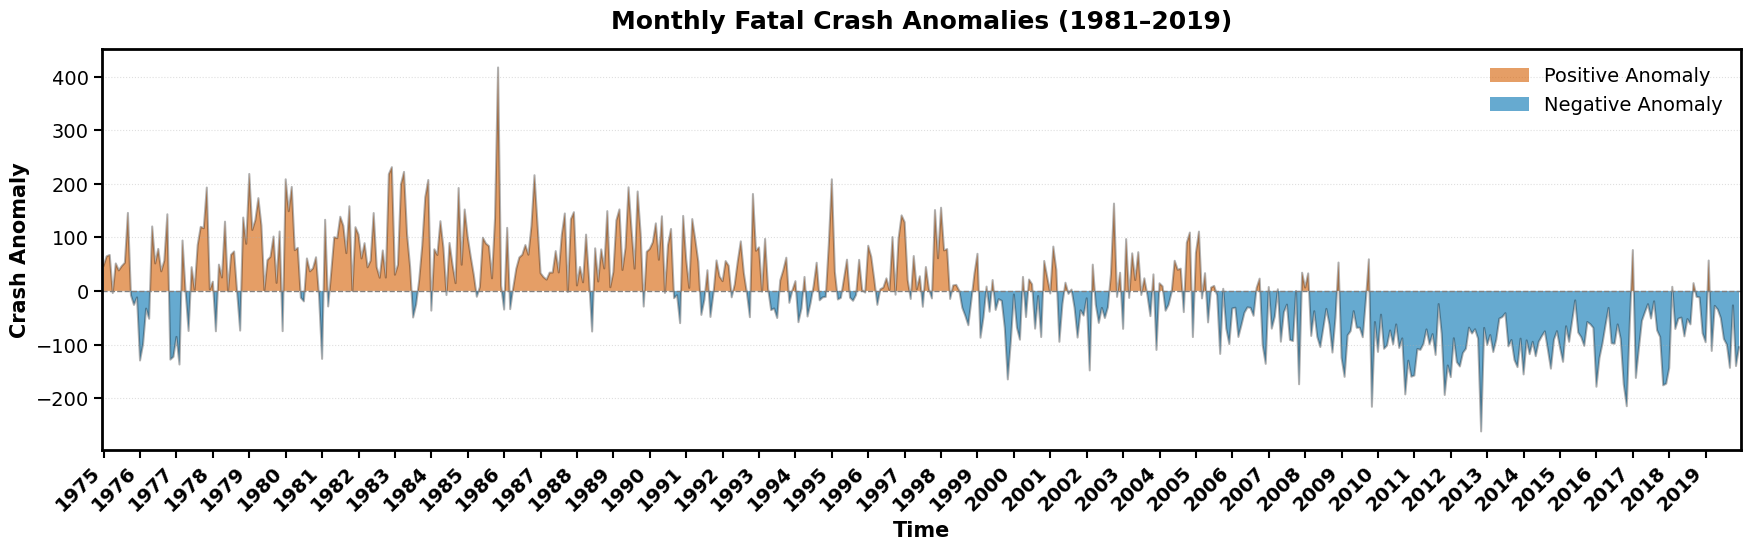

In [27]:
plot_crash_anomalies(crash_anomalies)

## Figure 5 Nino3.4

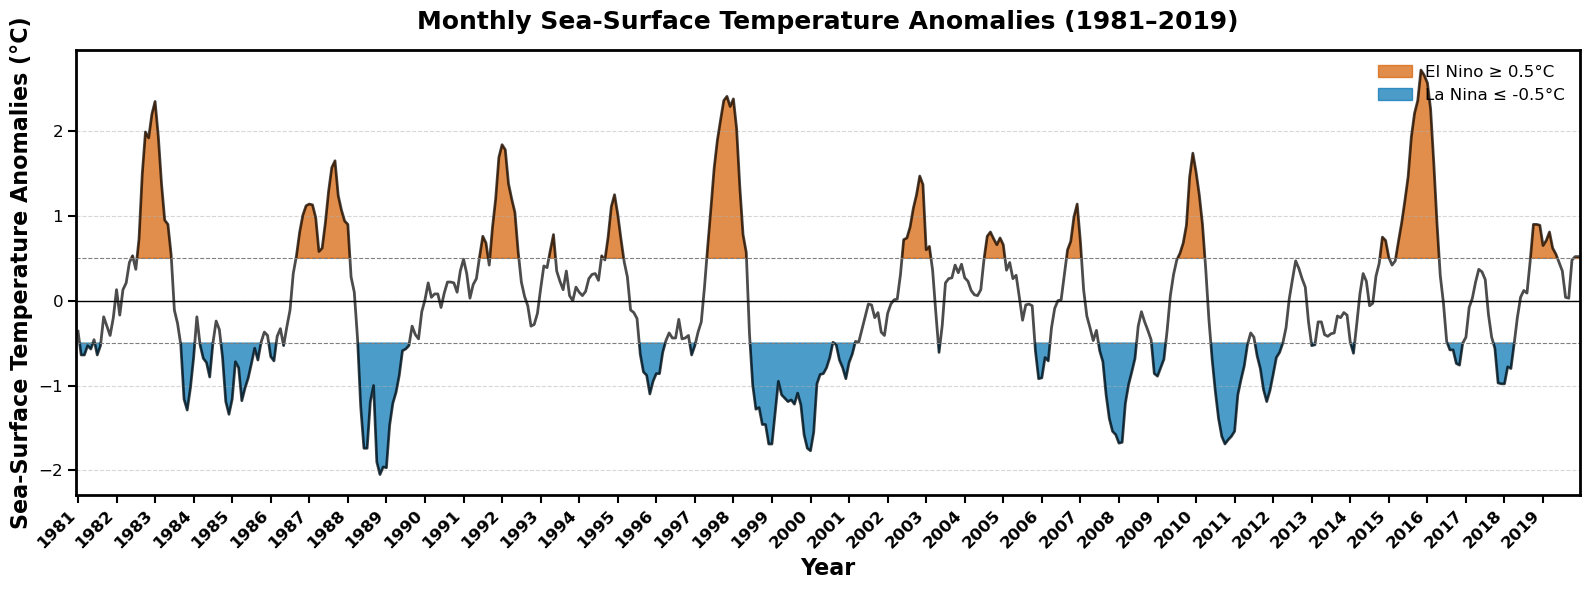

In [28]:
plot_nino34(df_enso)

# 2. Process Get Precip Data

In [29]:
# Filter to only 1981–2019
df_filtered = df_fars[(df_fars['YEAR'] >= 1981) & (df_fars['YEAR'] <= 2019)].copy()

# Function to classify weather type based on WEATHER code and YEAR
def classify_precip(row):
    code, year = row['WEATHER'], row['YEAR']
    if code == 5:
        return 'Non-Precipitation'
    elif code in [6, 7]:
        return 'Non-Precipitation' if year >= 2007 else 'Precipitation'
    else:
        return 'Precipitation'

# Apply classification
df_filtered.loc[:, 'WEATHER_TYPE'] = df_filtered.apply(classify_precip, axis=1)

# Count crashes by WEATHER code and WEATHER_TYPE
counts = (
    df_filtered
    .groupby(['WEATHER_TYPE', 'WEATHER'])
    .size()
    .reset_index(name='CRASH_COUNT')
)

# Pivot for table-style output
pivot = (
    counts
    .pivot(index='WEATHER', columns='WEATHER_TYPE', values='CRASH_COUNT')
    .fillna(0)
    .astype(int)
)

# Display result
print(pivot)

WEATHER_TYPE  Non-Precipitation  Precipitation
WEATHER                                       
2                             0         116741
3                             0           4543
4                             0          22098
5                         18902              0
6                           656           1385
7                           148            176
11                            0            290
12                            0            163


In [30]:
print(df_fars['WEATHER'].value_counts())

WEATHER
2     140176
4      26368
5      19570
3       5123
6       2041
7        324
11       290
12       163
Name: count, dtype: int64


## Nino34 Precip Anomaly bar Plots & Figs 6-7

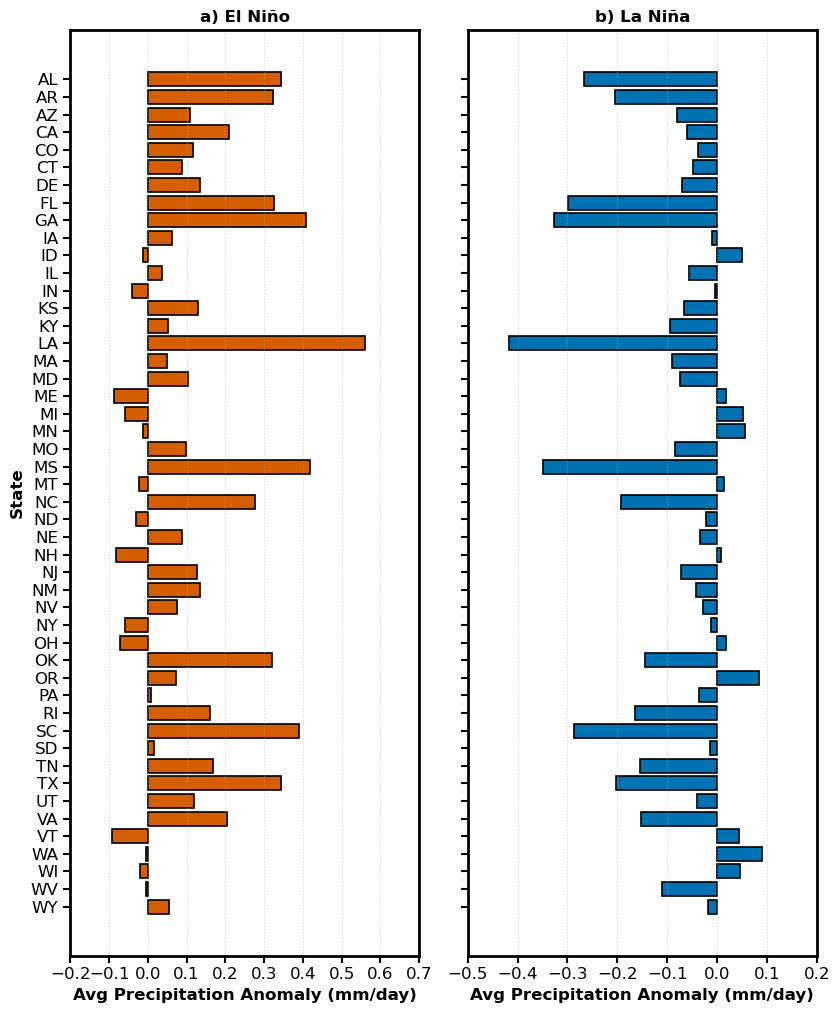

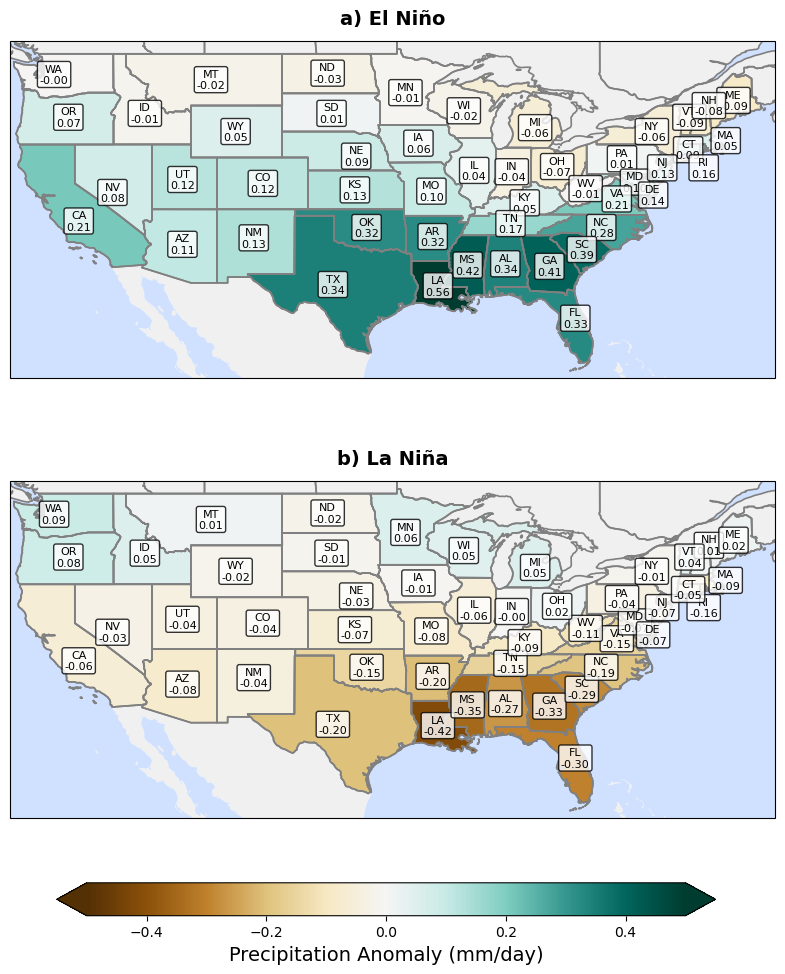

In [31]:
# Compute El Niño and La Niña average precipitation anomalies
el_nino_precip_df, la_nina_precip_df = compute_enso_avg_anomalies(df_precip, 'Precip_Anomaly_')
el_nino_avgs = el_nino_precip_df['Avg_Anomaly'].to_dict()
la_nina_avgs = la_nina_precip_df['Avg_Anomaly'].to_dict()

# Plot precipitation anomalies for El Niño and La Niña
plot_enso_precip_anomalies(el_nino_avgs, la_nina_avgs,save_path='../figs/enso_precip.png')

# Plot state-level anomaly maps for El Niño and La Niña
plot_enso_anomaly_maps(el_nino_avgs, la_nina_avgs, state_centers)


## Figures 8-9

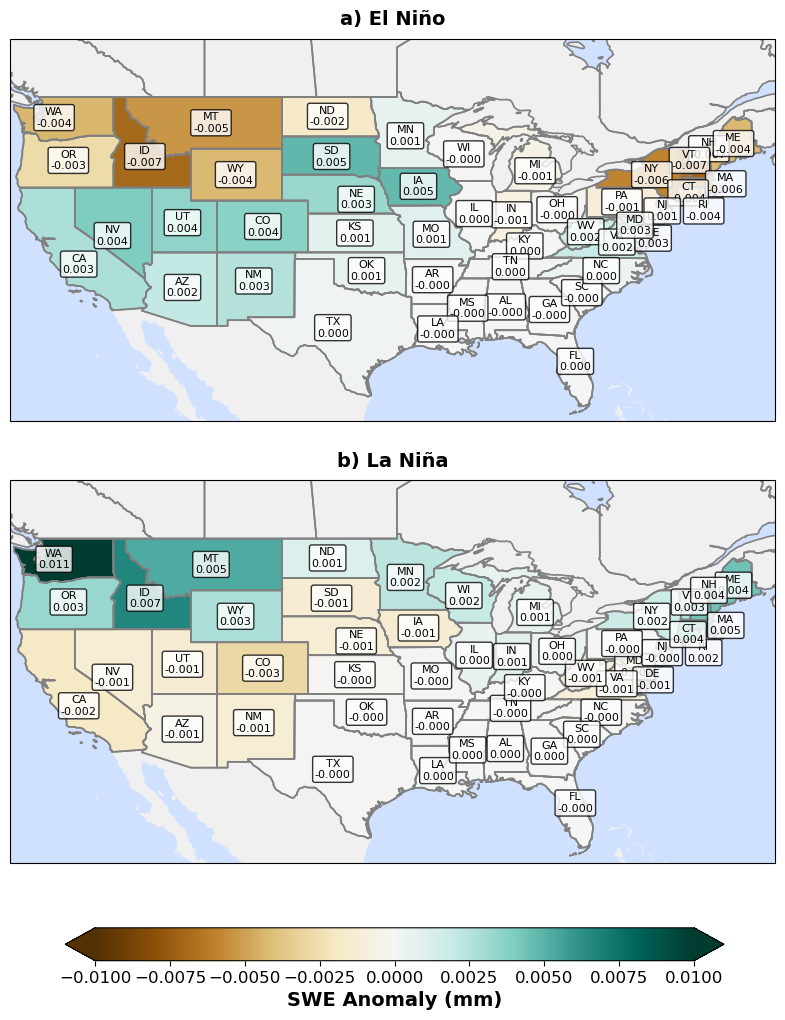

In [32]:
# Prepare ENSO data from precip_data for merging
enso_data = df_precip[['YEAR', 'Month', 'ENSO_Value']].copy()
enso_data['MONTH'] = enso_data['Month'].map(month_map)

# Filter for winter months (Dec, Jan, Feb) and years 2003+
enso_winter = enso_data[enso_data['MONTH'].isin([12, 1, 2])]
enso_winter = enso_winter[enso_winter['YEAR'] >= 2003]

# Merge with SWE data (now called sqm instead of merged_data)
swe_winter = df_swe[df_swe['MONTH'].isin([12, 1, 2])]  # Filter for winter months
swe_winter = pd.merge(swe_winter, enso_winter, on=['YEAR', 'MONTH'], how='inner')
swe_winter['snow_water_equivalent_IA']

# Compute average anomalies
el_nino_swe_df, la_nina_swe_df = compute_enso_avg_anomalies(swe_winter, 'snow_water_equivalent_')
el_nino_swe_avgs = el_nino_swe_df['Avg_Anomaly'].to_dict()
la_nina_swe_avgs = la_nina_swe_df['Avg_Anomaly'].to_dict()
plot_swe_anomaly_maps(el_nino_swe_avgs, la_nina_swe_avgs, state_centers)

## Figure 10

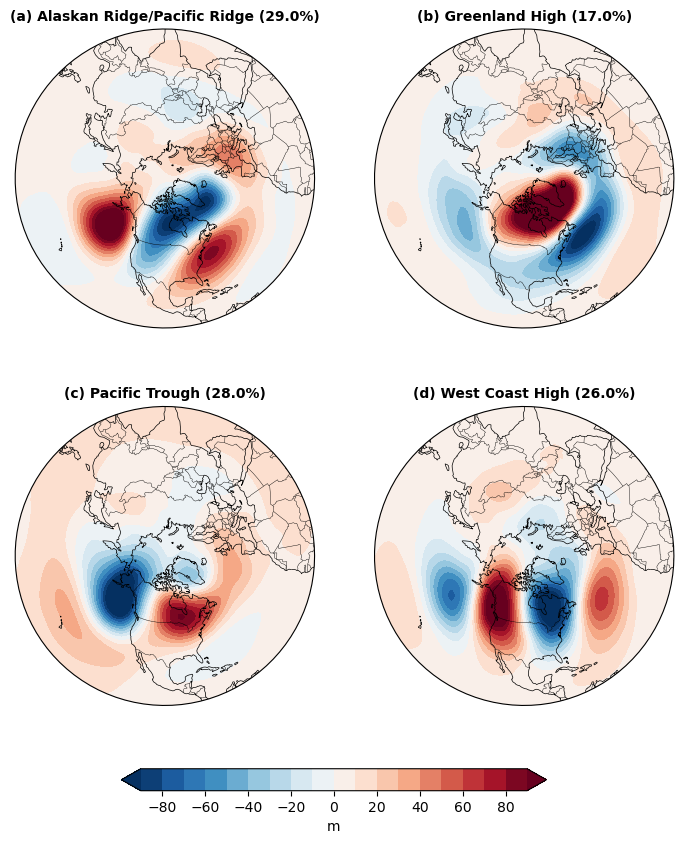

In [33]:
plot_cluster_composites(ds_comp, cmap='RdBu_r', lon_0=260,
                        suptitle=None, 
                        nrows=2, ncols=2, 
                        levels=np.arange(-90, 100, 10),
                        dpi=300,
                        save_path="../figs/cluster_composites_djf.png")

## Figure 11

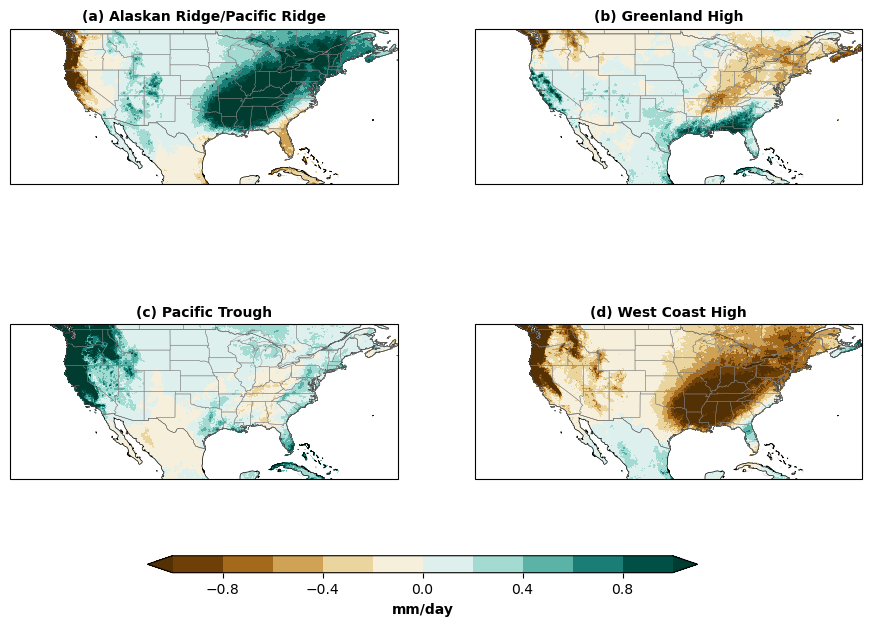

In [34]:
plot_precip_cluster_composites(ds_pcomp,titles=ds_comp['names'].values)

# 4. Calculate Precip and FWRCA Rsquared

In [35]:
# Fix df_precip month format and column name
if df_precip['Month'].dtype == 'object':
    df_precip['Month'] = df_precip['Month'].str.upper().map(month_map)

# Assume df_precip has ENSO_Value by YEAR-Month
enso_data = df_precip[['YEAR', 'Month', 'ENSO_Value']].drop_duplicates()

# Ensure df_swe['Month'] is int
df_swe = df_swe.rename(columns={'MONTH': 'Month'})
if df_swe['Month'].dtype == 'object':
    df_swe['Month'] = df_swe['Month'].str.upper().map(month_map)

# Merge ENSO into SWE
df_swe = df_swe.merge(enso_data, on=['YEAR', 'Month'], how='left')

# Compute FWRCA and R-squared with precip and swe
results_precip = compute_fwrca(df_fars, df_precip, state_dictAB, var_prefix='Precip')
results_swe = compute_fwrca(df_fars, df_swe, state_dictAB, var_prefix='SWE')

# Combine into a single DataFrame
results_all = pd.concat([results_precip, results_swe], ignore_index=True)

Missing required columns for AK (Precip), skipping...
Missing required columns for DC (Precip), skipping...
Missing required columns for HI (Precip), skipping...
Missing required columns for AK (SWE), skipping...
Missing required columns for HI (SWE), skipping...


In [36]:
enso_data

,YEAR,Month,ENSO_Value
0,1981,1,-0.36
1,1981,2,-0.64
2,1981,3,-0.64
3,1981,4,-0.53
4,1981,5,-0.57
...,...,...,...
475,2020,8,-0.59
476,2020,9,-0.83
477,2020,10,-1.26
478,2020,11,-1.42


In [37]:
df_swe

,YEAR,Month,snow_water_equivalent_AL,snow_water_equivalent_AR,snow_water_equivalent_AZ,snow_water_equivalent_CA,snow_water_equivalent_CO,snow_water_equivalent_CT,snow_water_equivalent_DC,snow_water_equivalent_DE,...,snow_water_equivalent_TN,snow_water_equivalent_TX,snow_water_equivalent_UT,snow_water_equivalent_VA,snow_water_equivalent_VT,snow_water_equivalent_WA,snow_water_equivalent_WI,snow_water_equivalent_WV,snow_water_equivalent_WY,ENSO_Value
0,2003,12,-0.000055,-0.000389,-0.002016,-0.000241,-0.008995,-0.001950,0.000379,-0.001004,...,-0.000062,-0.000226,-0.006577,-0.000454,0.040501,-0.006825,-0.005863,0.002593,-0.007977,0.43
1,2004,1,-0.000042,-0.000809,-0.004410,0.003962,-0.010982,-0.005704,-0.000024,0.000919,...,-0.000386,-0.000380,-0.008167,-0.000438,0.020087,-0.021728,-0.019743,-0.002684,-0.010632,0.27
2,2004,2,-0.000127,0.001030,-0.003716,-0.000555,-0.012125,-0.003209,-0.001516,-0.003499,...,-0.000672,-0.000186,-0.008930,0.000679,0.035055,-0.035120,0.007276,0.007464,-0.016634,0.23
3,2004,12,-0.000047,0.000382,-0.001208,0.002692,-0.002685,-0.003200,-0.001175,-0.001096,...,0.001510,-0.000165,0.001540,-0.001902,-0.010315,-0.031505,-0.007718,-0.002781,-0.014844,0.74
4,2005,1,-0.000137,-0.000741,-0.001809,0.014810,-0.003322,0.005362,-0.001027,0.001496,...,-0.000669,-0.000304,0.004390,-0.001160,-0.020361,-0.070756,-0.008068,-0.002076,-0.020380,0.66
5,2005,2,-0.000131,-0.001043,-0.001161,0.013319,0.000049,-0.011219,-0.003961,-0.000256,...,-0.000922,-0.000262,0.009607,-0.002393,-0.014425,-0.103002,-0.022183,-0.005844,-0.029381,0.36
6,2005,12,-0.000028,-0.000362,-0.002048,-0.002895,-0.004489,0.007354,0.000512,0.002468,...,-0.000369,-0.000192,-0.006698,0.003743,0.003543,-0.002846,-0.000222,0.002926,-0.001471,-0.92
7,2006,1,-0.000172,-0.000821,-0.004431,-0.000399,-0.011906,0.001406,-0.002740,-0.001745,...,-0.000790,-0.000382,-0.011220,-0.002008,-0.009238,0.006133,-0.017606,-0.005388,-0.004236,-0.91
8,2006,2,-0.000128,-0.000436,-0.004716,-0.007280,-0.020893,-0.019919,-0.002644,-0.003843,...,0.000585,-0.000296,-0.015057,-0.002752,-0.047362,0.028841,-0.023812,-0.006876,-0.004829,-0.67
9,2006,12,-0.000055,-0.000296,-0.001556,-0.006908,0.001062,-0.004962,-0.001175,-0.001136,...,-0.000460,0.000113,-0.005440,-0.001993,-0.021105,0.039007,-0.014458,-0.003775,-0.009053,1.14


## Figures 12 & 13

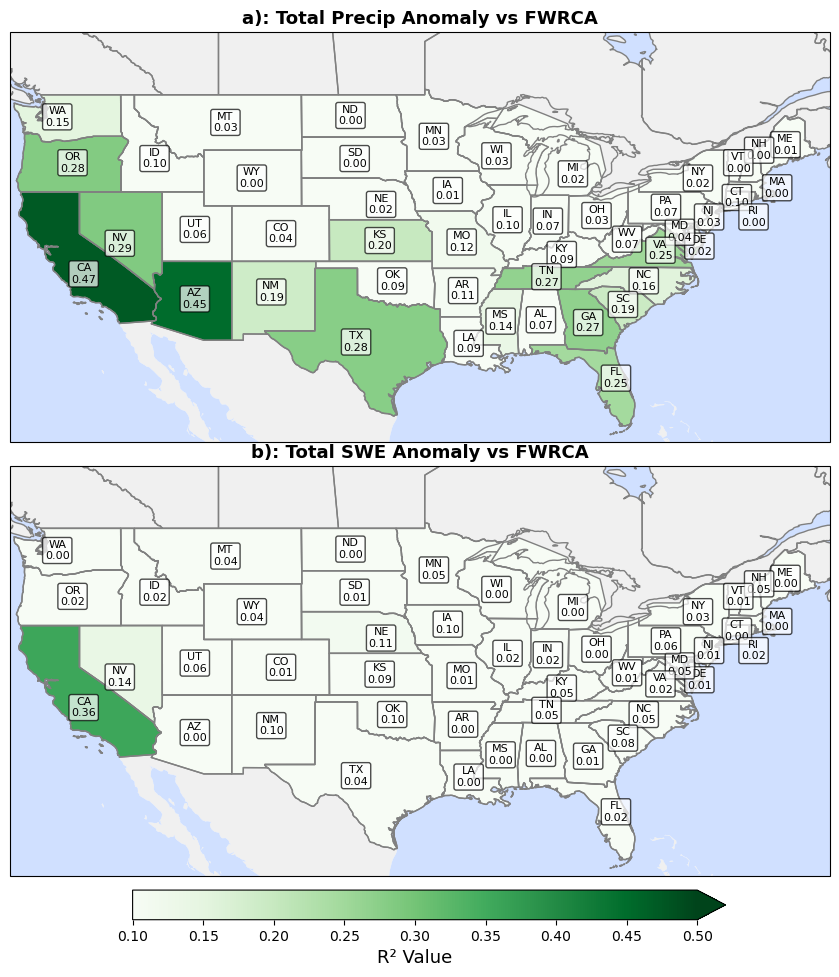

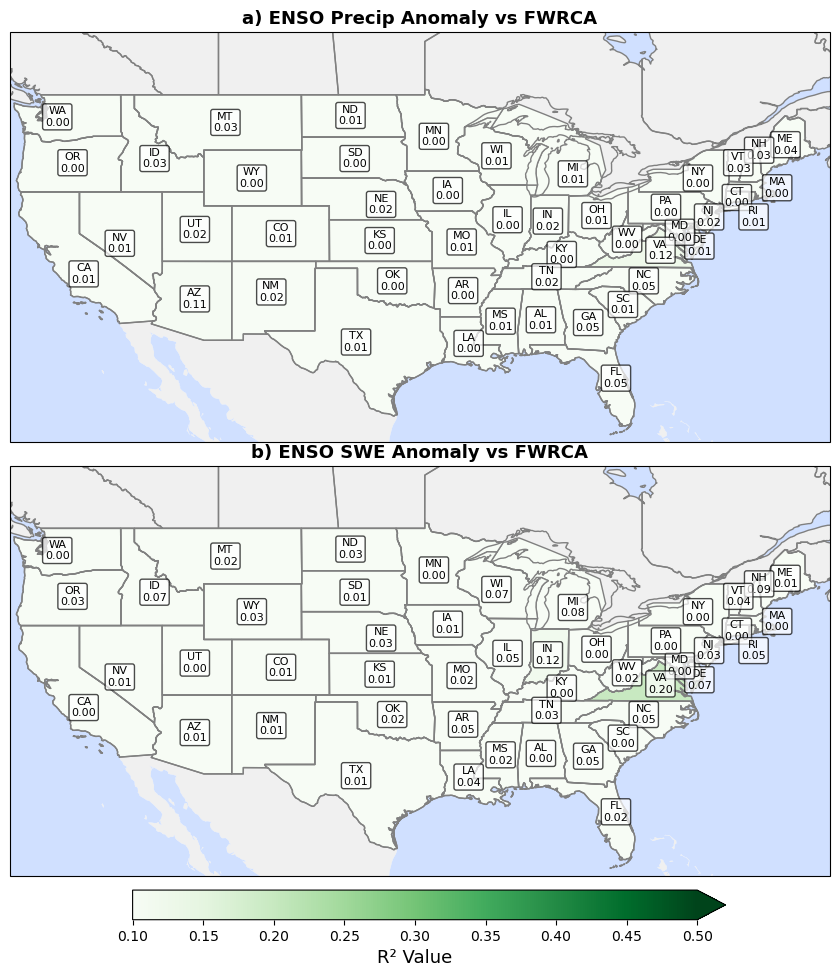

In [38]:
plot_r2_map_panels(results_all, state_centers, filename_base="fwrca_r2")

## Figure 18

In [39]:
# Load FARS crash data
# Assumes df_fars has: YEAR, MONTH, DAY, STATE (FIPS code)
# Load ds_cd (weather regime clusters) and ds_comp (regime names)
# Load states_map shapefile
states_map = gpd.read_file('../data/state_shape_file/cb_2018_us_state_20m.shp')
states_map['STATEFP'] = states_map['STATEFP'].astype(str).str.zfill(2)

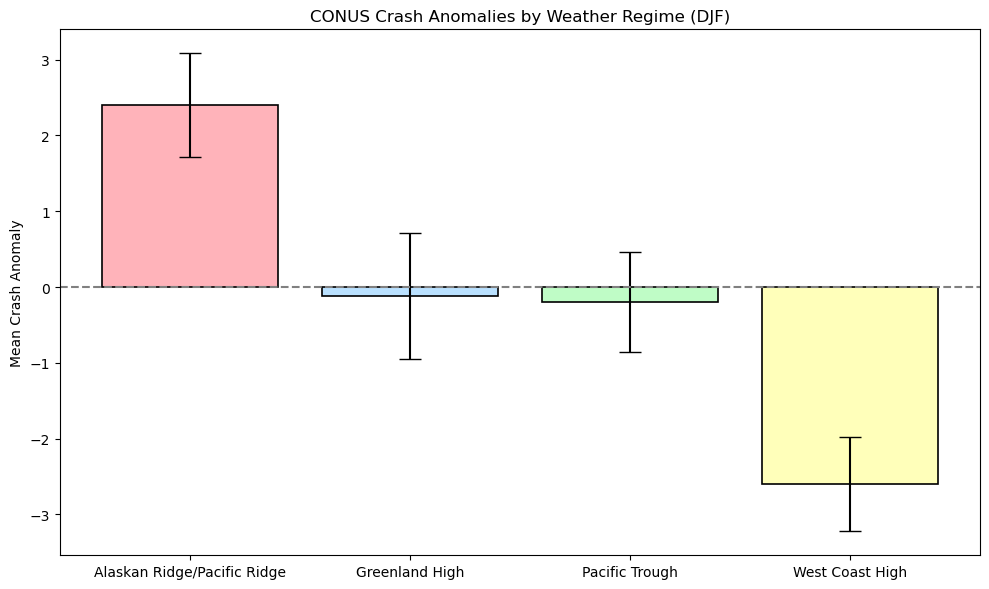

In [40]:
# 1. Add DATE and daily crash counts
df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')
conus_daily = df_fars.groupby('DATE').size().reset_index(name='CRASH_COUNT')
conus_daily['DOY'] = conus_daily['DATE'].dt.dayofyear

# 2. Daily climatology and anomaly
climatology = conus_daily.groupby('DOY')['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')
conus_daily = conus_daily.merge(climatology, on='DOY')
conus_daily['CRASH_ANOMALY'] = conus_daily['CRASH_COUNT'] - conus_daily['CLIM_MEAN']

# 3. Merge with regime labels (DJF only)
filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin([12, 1, 2]))
df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
df_clusters['DATE'] = pd.to_datetime(df_clusters['DATE'])
df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

merged = conus_daily.merge(df_clusters, on='DATE', how='inner')

# 4. Mean anomaly and CI
mean_anomaly_by_regime = merged.groupby('REGIME')['CRASH_ANOMALY'].mean()
counts_by_regime = merged.groupby('REGIME').size()
effective_n = (counts_by_regime / 28).astype(int)

ci = {}
for reg in mean_anomaly_by_regime.index:
    sample = merged.loc[merged['REGIME'] == reg, 'CRASH_ANOMALY']
    sem = sample.sem()
    dfree = effective_n[reg] - 1
    ci[reg] = stats.t.ppf(0.975, df=dfree) * sem if dfree > 0 else np.nan

regime_names = {i: str(name.values) for i, name in enumerate(ds_comp['names'])}
labels = [regime_names[r] for r in mean_anomaly_by_regime.index]

# 5. Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FFB3BA', '#BAE1FF', '#BFFCC6', '#FFFFBA']
ax.bar(
    labels, mean_anomaly_by_regime.values,
    yerr=[ci[r] for r in mean_anomaly_by_regime.index],
    color=colors[:len(labels)],
    edgecolor='black', capsize=8, linewidth=1.2
)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('Mean Crash Anomaly')
ax.set_title('CONUS Crash Anomalies by Weather Regime (DJF)')
plt.tight_layout()
plt.show()


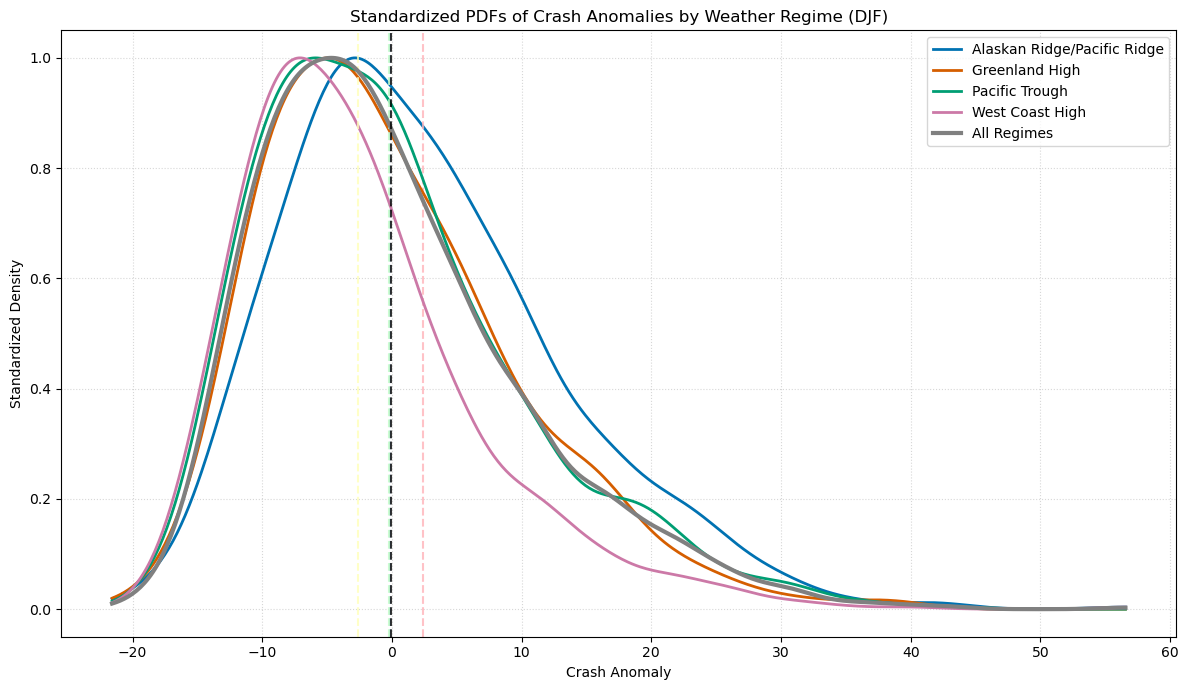

In [41]:
pdf_colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
x_grid = np.linspace(merged['CRASH_ANOMALY'].min(), merged['CRASH_ANOMALY'].max(), 500)

plt.figure(figsize=(12, 7))
for i, reg in enumerate(sorted(merged['REGIME'].unique())):
    data = merged.loc[merged['REGIME'] == reg, 'CRASH_ANOMALY'].dropna()
    if len(data) < 2:
        continue
    pdf = gaussian_kde(data)(x_grid)
    pdf /= pdf.max()
    plt.plot(x_grid, pdf, label=regime_names[reg], color=pdf_colors[i], linewidth=2)
    plt.axvline(data.mean(), color=colors[i], linestyle='--', alpha=0.8)

# Plot overall
all_data = merged['CRASH_ANOMALY'].dropna()
pdf_all = gaussian_kde(all_data)(x_grid)
pdf_all /= pdf_all.max()
plt.plot(x_grid, pdf_all, color='gray', linewidth=3, label='All Regimes')
plt.axvline(all_data.mean(), color='black', linestyle='--', alpha=0.8)

plt.xlabel('Crash Anomaly')
plt.ylabel('Standardized Density')
plt.title('Standardized PDFs of Crash Anomalies by Weather Regime (DJF)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


In [42]:
# Compute anomalies
mean_by_regime_state = compute_statewise_regime_anomalies(df_fars, ds_cd, ds_comp)

# Merge with shapefile
gdf = states_map.merge(mean_by_regime_state, left_on='STATEFP', right_on='STATE', how='left')
gdf['ANOMALY'] = gdf['CRASH_ANOMALY']  # rename for compatibility
gdf['REGIME_LABEL'] = gdf['REGIME'].map(regime_names)

# Filter states_map and gdf to only include CONUS states
conus_fips = [f"{i:02d}" for i in range(1, 57) if i not in {2, 15}]  # 01–56, excluding AK (02) and HI (15)
gdf_conus = gdf[gdf['STATEFP'].isin(conus_fips)]

AttributeError: 'list' object has no attribute 'Normalize'

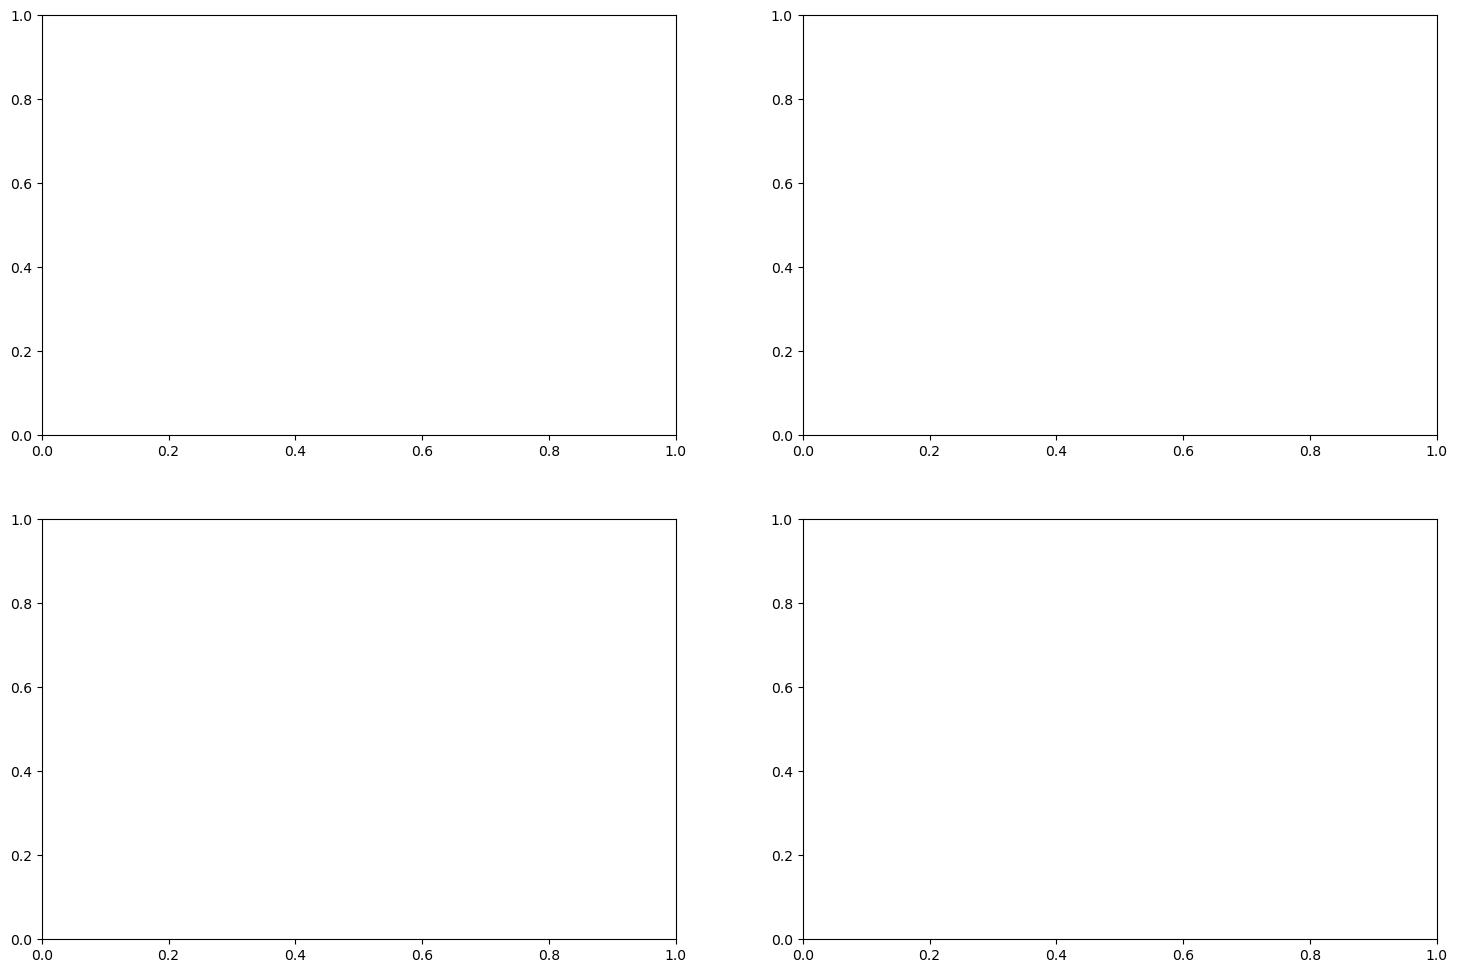

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

cmap_name = 'RdBu_r'
cmap = cm.get_cmap(cmap_name)

# Color normalization based on anomaly extremes
abs_max = max(abs(gdf_conus['ANOMALY'].min()), abs(gdf_conus['ANOMALY'].max()))
norm = colors.Normalize(vmin=-abs_max, vmax=abs_max)

subplot_labels = ['(a)', '(b)', '(c)', '(d)']
regimes_sorted = sorted(gdf_conus['REGIME'].dropna().unique())

# Get CONUS bounding box to fix axis limits
minx, miny, maxx, maxy = gdf_conus.total_bounds

for i, (regime, ax) in enumerate(zip(regimes_sorted, axes.flatten())):
    subset = gdf_conus[gdf_conus['REGIME'] == regime]

    # Plot choropleth
    subset.plot(
        column='ANOMALY',
        cmap=cmap_name,
        norm=norm,
        linewidth=0.8,
        edgecolor='black',
        ax=ax,
        legend=False,
    )

    # Fix map extent and aspect
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect('equal')
    ax.margins(0)

    # Add numeric labels inside each state
    for idx, row in subset.iterrows():
        if row['geometry'].is_empty or pd.isna(row['ANOMALY']):
            continue
        x, y = row['geometry'].centroid.coords[0]

        ax.text(
            x, y,
            f"{row['ANOMALY']:.2f}",  # Show anomaly value with 2 decimal places
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='black',
            clip_on=False,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='white')]
        )

    label = regime_names.get(regime, f'Regime {regime}')
    ax.set_title(f"{subplot_labels[i]} {label}", loc='left', fontsize=14)

    ax.set_xticks([])
    ax.set_yticks([])

# Create ScalarMappable for colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

# Add colorbar axis below the plots
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # left, bottom, width, height in figure coords

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Average Anomalous Fatal Crashes per Day')

fig.suptitle('Average Anomalous Fatal Crashes by State and Weather Regime (DJF)', fontsize=18, y=0.95)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Leave space at bottom for colorbar
plt.show()

In [ ]:
# states_map already loaded
gdf_reg0 = compute_statewise_precip_averages(ds_chirps['precip'], states_map, regime_number=0)

# for all regimes
gdf_all = []
for reg in range(chirps_da.shape[0]):
    gdf = compute_statewise_precip_averages(chirps_da, states_map, regime_number=reg)
    gdf_all.append(gdf)

gdf_precip = pd.concat(gdf_all, ignore_index=True)
plot_statewise_precip_anomalies(gdf_precip=mean_precip_anom_by_state, regime_names=regime_names)